# Evaluación comparativa de arquitecturas Big Data

Objetivo: Construir una evaluación comparativa de alternativas arquitectónicas Big Data
a partir de evidencia experimental y criterios de selección. Este notebook contiene la
matriz de evaluación, el cálculo multicriterio simple, recomendaciones por escenario y
una discusión de trade-offs y limitaciones.

## Arquitecturas consideradas

Se comparan las siguientes alternativas (referencia):

- **A: Procesamiento local monolítico con archivos** (simple, bajo costo inicial).
- **B: Pipeline reproducible con Docker y almacenamiento columnar** (reproducible, optimizado para analítica).
- **C: Mini arquitectura con servicios conteinerizados** (microservicios ligeros, escalables).
- **D: Data lake / Lakehouse (conceptual)** (centralización de datos, flexibilidad de esquemas).
- **E: Arquitectura cloud o híbrida (conceptual)** (servicios gestionados, escalado elástico).

## Criterios y ponderaciones

Criterios usados (escala de 1 a 5, donde 5 es mejor) y ponderaciones (suma = 1):

- `rendimiento`: 0.18 — impacto en latencia y throughput.
- `costo_relativo`: 0.15 — coste total relativo (infraestructura y operación).
- `escalabilidad`: 0.15 — capacidad de crecer con volumen.
- `mantenibilidad`: 0.10 — facilidad para mantener y evolucionar.
- `reproducibilidad`: 0.07 — facilidad para reproducir pipelines/experimentos.
- `gobernanza`: 0.10 — control de datos, catálogo y linaje.
- `seguridad`: 0.10 — capacidad para proteger datos y accesos.
- `resiliencia`: 0.08 — tolerancia a fallos y recuperación.
- `complejidad_operativa`: 0.05 — coste operativo y overhead.
- `madurez_equipo`: 0.02 — nivel de experiencia requerido del equipo.

Justificación breve: las ponderaciones priorizan rendimiento, costo y escalabilidad porque
son frecuentemente determinantes al seleccionar infraestructuras Big Data; gobernanza y seguridad
reciben peso relevante en entornos regulados.

Matriz de puntuaciones (1-5):


,rendimiento,costo_relativo,escalabilidad,mantenibilidad,reproducibilidad,gobernanza,seguridad,resiliencia,complejidad_operativa,madurez_equipo
Monolito archivos,3,4,2,2,2,2,2,2,4,3
Pipeline Docker columnar,4,3,3,3,5,3,3,3,3,3
Mini servicios conteinerizados,4,3,4,4,4,3,3,4,3,4
Data Lake/Lakehouse,4,2,5,3,3,2,2,4,2,2
Cloud/Híbrida,5,2,5,4,4,4,4,5,3,3



Ranking por puntuación ponderada:


,arquitectura,score
Cloud/Híbrida,Cloud/Híbrida,4.04
Mini servicios conteinerizados,Mini servicios conteinerizados,3.60
Pipeline Docker columnar,Pipeline Docker columnar,3.32
Data Lake/Lakehouse,Data Lake/Lakehouse,3.14
Monolito archivos,Monolito archivos,2.60


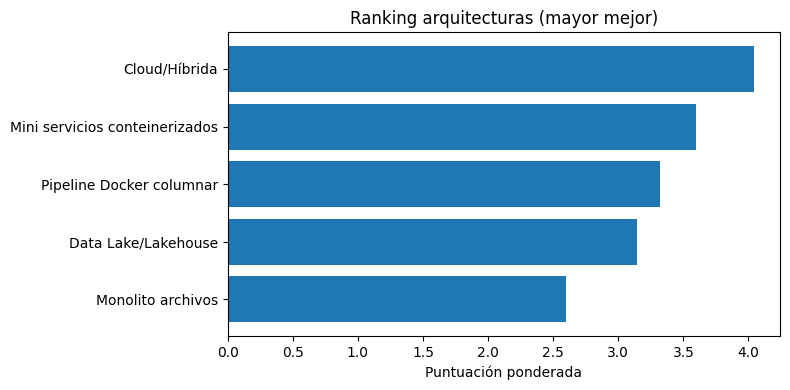

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Definición de arquitecturas y criterios
archs = [
    'Monolito archivos',
    'Pipeline Docker columnar',
    'Mini servicios conteinerizados',
    'Data Lake/Lakehouse',
    'Cloud/Híbrida'
]
criteria = [
    'rendimiento','costo_relativo','escalabilidad','mantenibilidad','reproducibilidad',
    'gobernanza','seguridad','resiliencia','complejidad_operativa','madurez_equipo'
]
weights = {
    'rendimiento':0.18,'costo_relativo':0.15,'escalabilidad':0.15,'mantenibilidad':0.10,
    'reproducibilidad':0.07,'gobernanza':0.10,'seguridad':0.10,'resiliencia':0.08,
    'complejidad_operativa':0.05,'madurez_equipo':0.02
}
# Puntuaciones estimadas (1-5). Estas son inicialmente heurísticas y deben respaldarse con datos experimentales
scores = {
    'Monolito archivos':          [3,4,2,2,2,2,2,2,4,3],
    'Pipeline Docker columnar':   [4,3,3,3,5,3,3,3,3,3],
    'Mini servicios conteinerizados':[4,3,4,4,4,3,3,4,3,4],
    'Data Lake/Lakehouse':        [4,2,5,3,3,2,2,4,2,2],
    'Cloud/Híbrida':              [5,2,5,4,4,4,4,5,3,3]
}
# Construir DataFrame
df = pd.DataFrame.from_dict(scores, orient='index', columns=criteria)
df['arquitectura'] = df.index
# Calcular puntuación ponderada
weight_series = pd.Series(weights)
df['score'] = df[criteria].mul(weight_series).sum(axis=1)
df_sorted = df.sort_values('score', ascending=False)

# Mostrar resultados
print('Matriz de puntuaciones (1-5):')
display(df[criteria])
print('\nRanking por puntuación ponderada:')
display(df_sorted[['arquitectura','score']])

# Gráfica simple
plt.figure(figsize=(8,4))
plt.barh(df_sorted['arquitectura'], df_sorted['score'], color='C0')
plt.xlabel('Puntuación ponderada')
plt.title('Ranking arquitecturas (mayor mejor)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Recomendaciones por escenario

Las recomendaciones siguientes se derivan del ranking y de las fortalezas/debilidades de cada alternativa: 

- **Equipo pequeño con recursos limitados:** `Monolito archivos` o `Pipeline Docker columnar` (si el equipo puede adoptar Docker). El monolito minimiza coste inicial y complejidad; el pipeline Docker aporta reproducibilidad si se puede asumir la curva de aprendizaje.
- **Organización con crecimiento de volumen:** `Cloud/Híbrida` o `Data Lake/Lakehouse`. Permiten escalado elástico y manejo de grandes volúmenes; elegir cloud gestionada reduce trabajo operativo pero aumenta coste relativo.
- **Organización regulada:** `Cloud/Híbrida` con enfoque en gobernanza o `Pipeline Docker columnar` con controles de linaje y catálogo; priorizar gobernanza y seguridad aún si sube coste.
- **Caso de datos semiestructurados / eventos continuos:** `Mini servicios conteinerizados` o `Cloud/Híbrida`. Arquitecturas por servicios facilitan ingestión continua y micro-batching/streaming; cloud brinda servicios gestionados para eventos.

## Discusión de trade-offs y limitaciones

- Las puntuaciones aquí son inicialmente heurísticas; la evaluación sólida requiere evidencia experimental: benchmarks de throughput/latencia, estimaciones de coste reales, pruebas de resiliencia y mediciones de operativa.
- Los pesos reflejan prioridades que pueden cambiar por escenario: en entornos regulados `gobernanza` y `seguridad` deberían recibir mayor peso.
- Las arquitecturas conceptuales (`Data Lake`, `Cloud`) requieren diseño detallado (servicios, configuración, proveedores) y por tanto su comparación aquí es de alto nivel.
- Recomendación metodológica: realizar experimentos controlados para medir `rendimiento` y `costo` por carga representativa, luego re-calibrar la matriz y repetir el ranking.

Si quieres, puedo: (1) convertir estas puntuaciones en un experimento reproducible (scripts y datos de prueba),
(2) ajustar las ponderaciones para un escenario concreto, o (3) exportar la tabla a CSV/Markdown. ¿Qué prefieres?